## Vortex Pannel Method

In [43]:
#Libraries
import numpy as np
import numpy.linalg as la
import matplotlib.pyplot as plt


In [44]:
def diff(x):
    return x[1:] - x[:-1]

In [45]:
#generaing NACA 2412 airfoil coordinates
def naca4(digits, n=100, finite_TE=False):
    m = int(digits[0]) / 100        
    p = int(digits[1]) / 10         
    t = int(digits[2:]) / 100       

    beta = np.linspace(0, np.pi, n+1)
    xc = (1 - np.cos(beta)) / 2     

    # Thickness distribution
    yt = 5*t * (0.2969*np.sqrt(xc) - 0.1260*xc
                - 0.3516*xc**2 + 0.2843*xc**3
                - (0.1015 if finite_TE else 0.1036)*xc**4)

    # Camber line and gradient
    yc    = np.where(xc < p,
                     m/p**2 * (2*p*xc - xc**2),
                     m/(1-p)**2 * (1 - 2*p + 2*p*xc - xc**2))
    dyc   = np.where(xc < p,
                     2*m/p**2 * (p - xc),
                     2*m/(1-p)**2 * (p - xc))
    theta_c = np.arctan(dyc)

    xu = xc - yt*np.sin(theta_c)
    yu = yc + yt*np.cos(theta_c)
    xl = xc + yt*np.sin(theta_c)
    yl = yc - yt*np.cos(theta_c)

    # Concatenate upper (LE→TE) then lower (TE→LE) for a closed loop
    # CLOCKWISE ordering
    x = np.concatenate([xl[::-1], xu[1:]])
    y = np.concatenate([yl[::-1], yu[1:]])  
    return x, y

x, y = naca4('2412', n=100)
num_panels = len(x) - 1
print(x,y)


[ 1.00000000e+00  9.99750896e-01  9.99003847e-01  9.97759637e-01
  9.96019577e-01  9.93785495e-01  9.91059738e-01  9.87845168e-01
  9.84145156e-01  9.79963578e-01  9.75304811e-01  9.70173723e-01
  9.64575668e-01  9.58516481e-01  9.52002465e-01  9.45040384e-01
  9.37637457e-01  9.29801344e-01  9.21540140e-01  9.12862360e-01
  9.03776934e-01  8.94293191e-01  8.84420850e-01  8.74170009e-01
  8.63551131e-01  8.52575034e-01  8.41252877e-01  8.29596150e-01
  8.17616659e-01  8.05326512e-01  7.92738109e-01  7.79864128e-01
  7.66717509e-01  7.53311442e-01  7.39659354e-01  7.25774894e-01
  7.11671916e-01  6.97364471e-01  6.82866785e-01  6.68193249e-01
  6.53358404e-01  6.38376922e-01  6.23263596e-01  6.08033321e-01
  5.92701081e-01  5.77281931e-01  5.61790985e-01  5.46243400e-01
  5.30654359e-01  5.15039057e-01  4.99412686e-01  4.83790423e-01
  4.68187411e-01  4.52618748e-01  4.37099472e-01  4.21644548e-01
  4.06268854e-01  3.91060657e-01  3.76013033e-01  3.61089247e-01
  3.46303015e-01  3.31667

In [46]:
# actual method
def vortex_panel(coords, alpha):
    x = coords[:,0]
    y = coords[:,1]
    num_panels = x.shape[0] - 1
    print('Panels:', num_panels)
    # angle of attack
    alpha_rad = alpha/180 * np.pi
    # calculate the position of the control point
    x_c = (x[:-1] + x[1:]) / 2
    y_c = (y[:-1] + y[1:]) / 2
    # calculate the length of each panel and the angle
    dx = diff(x)
    dy = diff(y)
    S = np.sqrt(dx**2 + dy**2)
    theta = np.arctan2(dy, dx)
    C_n1 = np.zeros((num_panels, num_panels))
    C_n2 = np.zeros((num_panels, num_panels))
    C_t1 = np.zeros((num_panels, num_panels))
    C_t2 = np.zeros((num_panels, num_panels))
    A_n = np.zeros((num_panels+1, num_panels+1))
    A_t = np.zeros((num_panels+1, num_panels+1))
    RHS = np.zeros((num_panels+1,1))
    for i in range(num_panels):
        for j in range(num_panels):
            if j != i:
                # I recomend splitting up the terms like this
                # feel free to do something else if it makes more sense to you
                A = -(x_c[i] - x[j])*np.cos(theta[j]) - (y_c[i] - y[j])*np.sin(theta[j])
                B = (x_c[i] - x[j])**2 + (y_c[i] - y[j])**2
                C = np.sin(theta[i] - theta[j])
                D = np.cos(theta[i] - theta[j])
                E = (x_c[i]-x[j])*np.sin(theta[j])-(y_c[i]-y[j])*np.cos(theta[j])
                F = np.log(1 + (S[j]*(S[j]+2*A))/B)
                G = np.arctan2(E*S[j],B+A*S[j])
                P = (x_c[i]-x[j])*np.sin(theta[i]-2*theta[j]) + (y_c[i]-y[j])*np.cos(theta[i]-2*theta[j]) #rem that there is weird fix here
                Q = (x_c[i]-x[j])*np.cos(theta[i]-2*theta[j]) - (y_c[i]-y[j])*np.sin(theta[i]-2*theta[j]) #rem that there is weird fix here
                # Based on the terms I used, these are the calculations
                # for the C values, but feel free to change these if you
                # want to set it up differently
                C_n2[i,j] = D + 0.5*Q*F/S[j] - (A*C + D*E)*G/S[j]
                C_n1[i,j] = 0.5*D*F + C*G - C_n2[i,j]
                C_t2[i,j] = C + 0.5*P*F/S[j]+(A*D - C*E)*G/S[j];
                C_t1[i,j] = 0.5*C*F - D*G - C_t2[i,j];
            # if i == j, you are calculated the effect of a panel on itself
            # and the geometry is a bit simpler
            else:
                C_n1[i,j] = -1
                C_n2[i,j] = 1
                C_t1[i,j] = 0.5*np.pi
                C_t2[i,j] = 0.5*np.pi
                # buld the A matrices for the linear equation
            if j == 0:
                A_n[i,j] = C_n1[i,j]
                A_t[i,j] = C_t1[i,j]
            elif j != 0:
                A_n[i,j] = C_n1[i,j] + C_n2[i,j-1]
                A_t[i,j] = C_t1[i,j] + C_t2[i,j-1]
        A_n[i,num_panels] = C_n2[i,num_panels-1]
        A_t[i,num_panels] = C_t2[i,num_panels-1]
        # put together the right hand side (sometimes written as the b vector)
        RHS[i,0] = np.sin(theta[i] - alpha_rad)
    A_n[num_panels,0] = 1
    A_n[num_panels,num_panels] = 1
    # solve the system of equations for gamma
    Gamma = la.solve(A_n, RHS)
    # print('Gamma full:', Gamma.flatten())
    # print('S full:', S)
    # print('Kutta check Gamma[0]+Gamma[-1]:', Gamma[0] + Gamma[-1])
    V = np.zeros((num_panels,1))
    Cp = np.zeros((num_panels,1))
    # calculate the velocity along each pannel using the tangential components
    Gamma_flat = Gamma.flatten()
    for i in range(num_panels):
        val = 0
        # add up the contributions to tangential velocity
        for j in range(num_panels):
            val += A_t[i,j]*Gamma[j]
        V[i] = np.cos(theta[i] - alpha_rad) + np.dot(A_t[i,:], Gamma_flat)
        # calculate the Cp
        Cp[i] = 1 - V[i]**2
    # Compute lift coefficient
    # CL = -np.sum(Cp.flatten() * S * np.sin(theta - alpha_rad))
    # normal vector components (pointing inward for clockwise winding)
    # Lift coefficient from circulation
    gamma_panel = 0.5 * (Gamma[:-1].flatten() + Gamma[1:].flatten())
    Gamma_total = np.sum(gamma_panel * S)
    chord = np.max(x) - np.min(x)
    CL = 4* np.pi * Gamma_total / chord   
    print(CL)
    print('V min/max:', V.min(), V.max())
    print('Cp min/max:', Cp.min(), Cp.max())
    return Cp, CL, Gamma

Panels: 60
0.9048737144176797
V min/max: -0.9327200035540256 1.7029902731247586
Cp min/max: -1.9001758703575398 0.9989178951735237
Panels: 80
0.9053816201301422
V min/max: -0.932839393463208 1.721524932653204
Cp min/max: -1.963648093746619 0.9755570034520543
Panels: 100
0.9056185701958032
V min/max: -0.9329146577515985 1.7310386224898746
Cp min/max: -1.9964947125516428 0.9993474305584737
Panels: 120
0.9057481825265603
V min/max: -0.9329661481878488 1.7347408199055026
Cp min/max: -2.009325712246415 0.9892753188278701
Panels: 140
0.9058258987921264
V min/max: -0.9330015225982676 1.7418755772206918
Cp min/max: -2.034130526517918 0.9994342449770489
Panels: 160
0.9058765031907623
V min/max: -0.9330286470370046 1.7437079533248772
Cp min/max: -2.040517426488432 0.994408419973968
Panels: 180
0.9059091836874013
V min/max: -0.9330496730932956 1.7471797572708687
Cp min/max: -2.0526371042170917 0.9994654545512738
Panels: 200
0.9059090069043847
V min/max: -0.9330660885489481 1.7492750090877696
Cp m

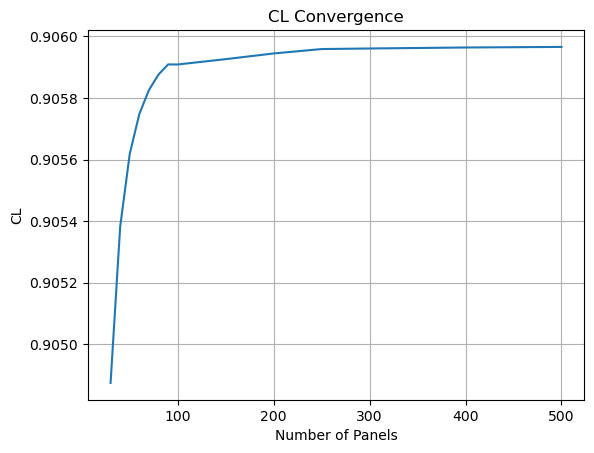

In [47]:
# Plotting

# create values
count_panel = [30, 40, 50, 60, 70, 80, 90, 100, 150, 200, 250, 300, 400, 500]
cl_sol = []
alpha = 5.37

# loop
for n in count_panel:
    x, y = naca4('2412', n=n)
    coords = np.column_stack((x, y))
    _, cl, _ = vortex_panel(coords, alpha)
    cl_sol.append(cl)

# plotting
plt.plot(count_panel, cl_sol)
plt.xlabel('Number of Panels')
plt.ylabel('CL')
plt.title('CL Convergence')
plt.grid(True)
plt.show()


In [48]:
def velocity_field(coords, Gamma, alpha_deg, X, Y):

    alpha = np.radians(alpha_deg)

    x = coords[:,0]
    y = coords[:,1]

    num_panels = len(x) - 1

    dx = np.diff(x)
    dy = np.diff(y)

    S = np.sqrt(dx**2 + dy**2)

    theta = np.arctan2(dy, dx)

    u = np.ones_like(X) * np.cos(alpha)
    v = np.ones_like(Y) * np.sin(alpha)

    Gamma = Gamma.flatten()

    for j in range(num_panels):

        # panel midpoint
        x_mid = 0.5*(x[j] + x[j+1])
        y_mid = 0.5*(y[j] + y[j+1])

        # approximate panel circulation
        gamma_j = 0.5*(Gamma[j] + Gamma[j+1])

        # point vortex approximation
        dx_field = X - x_mid
        dy_field = Y - y_mid

        r2 = dx_field**2 + dy_field**2

        r2[r2 < 1e-8] = 1e-8

        strength = gamma_j * S[j] / (2*np.pi)

        u += -strength * dy_field / r2
        v +=  strength * dx_field / r2

    return u, v

In [49]:
coords = np.column_stack((x,y))

Cp, CL, Gamma = vortex_panel(coords, alpha=5)

Panels: 1000
0.8616214869301624
V min/max: -0.9403653414542338 1.7053930221926483
Cp min/max: -1.9083653601433745 0.9999451431584443


In [50]:
# alpha_gay = 0.26/

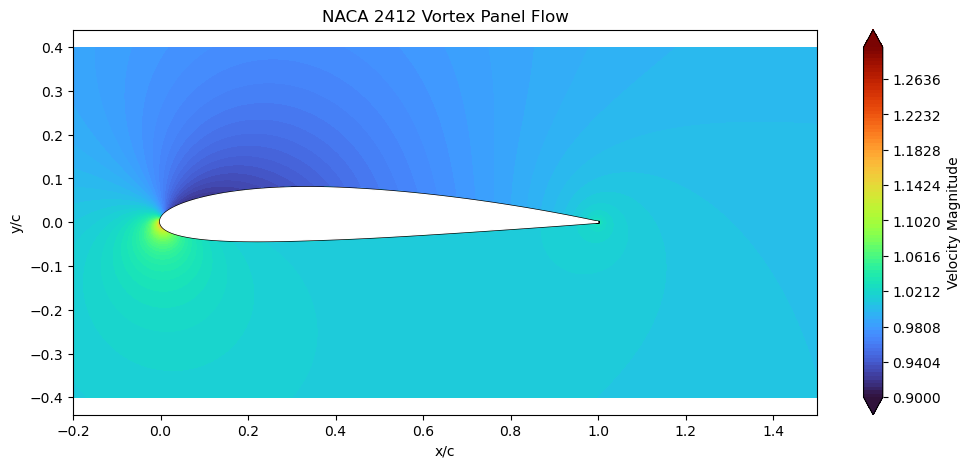

In [55]:
# ==========================================
# FLOW FIELD GRID
# ==========================================

x_grid = np.linspace(-0.2, 1.5, 250)
y_grid = np.linspace(-0.4, 0.4, 250)

X, Y = np.meshgrid(x_grid, y_grid)

u, v = velocity_field(
    coords,
    Gamma,
    alpha_deg=5,
    X=X,
    Y=Y
)

V_mag = np.sqrt(u**2 + v**2)

from matplotlib.path import Path

airfoil_path = Path(coords)

points = np.vstack(
    (X.flatten(), Y.flatten())
).T

mask = airfoil_path.contains_points(points)

mask = mask.reshape(X.shape)

V_mag[mask] = np.nan

plt.figure(figsize=(12,5))

contours = plt.contourf(
    X,
    Y,
    V_mag,
    levels=np.linspace(0.9, 1.3, 100),
    cmap='turbo',
    extend='both'
)

# plt.streamplot(
#     X,
#     Y,
#     u,
#     v,
#     color='k',
#     density=2,
#     linewidth=0.5
# )

plt.fill(
    coords[:,0],
    coords[:,1],
    color='white',
    zorder=10
)

plt.plot(
    coords[:,0],
    coords[:,1],
    color='black',
    linewidth=2
)

plt.colorbar(
    contours,
    label='Velocity Magnitude'
)

plt.title(
    f'NACA 2412 Vortex Panel Flow'
)

plt.xlabel('x/c')
plt.ylabel('y/c')

plt.axis('equal')

plt.show()